In [24]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams["figure.dpi"] = 100

TARGET = "us_aqi"
WEATHER_FEATURES = [
    "temp_max", "temp_min", "temp_mean", "humidity_mean",
    "rain_sum", "wind_speed_max",
]
POLLUTANT_FEATURES = ["pm2_5", "pm10", "nitrogen_dioxide"]
IMPORTANT_FEATURES = WEATHER_FEATURES + POLLUTANT_FEATURES + [TARGET]

In [25]:
df = pd.read_csv("pune_ml_training_data.csv")
df2 = pd.read_csv("fianl_pune_model_ready.csv")
df["day"] = pd.to_datetime(df["day"])
df2["day"] = pd.to_datetime(df2["day"])

df.sample(5)

,day,temp_max,temp_min,temp_mean,humidity_mean,rain_sum,wind_u_mean,wind_v_mean,wind_speed_max,pm2_5,pm10,nitrogen_dioxide,us_aqi
386,2024-01-21,28.95,14.50,20.888333,61.905602,0.0,-2.028000,-0.612000,10.594036,38.966667,58.833333,17.641667,102.500000
109,2023-04-19,38.75,20.90,30.160833,32.477674,1.2,1.488000,0.345000,23.166218,37.883333,54.720833,25.741667,115.208333
978,2025-09-04,26.65,20.95,23.240417,85.206340,7.0,15.553499,1.680006,23.304266,9.620833,16.991667,6.712500,46.708333
818,2025-03-28,37.65,20.25,29.467500,38.805372,0.0,2.593499,-1.255501,19.721298,25.687500,30.962500,14.100000,91.833333
17,2023-01-17,30.35,11.90,21.081667,52.754839,0.0,3.144000,0.045000,11.304229,63.550000,91.637500,12.050000,155.625000


In [26]:
print(f"Rows: {len(df):,}  |  Columns: {df.shape[1]}")
print(f"Date range: {df['day'].min().date()} → {df['day'].max().date()}")
print(f"Duplicates (day): {df['day'].duplicated().sum()}")
print(f"Missing values:\n{df.isnull().sum()[df.isnull().sum() > 0] if df.isnull().any().any() else 'None'}")

display(df.dtypes.to_frame("dtype"))
display(df.describe().T.round(2))

# Quick sanity checks
print(f"Days with rain: {(df['rain_sum'] > 0).sum()} ({(df['rain_sum'] > 0).mean():.1%})")
print(f"Negative values in numeric cols: {(df.select_dtypes('number') < 0).any().any()}")

Rows: 1,097  |  Columns: 13
Date range: 2022-12-31 → 2025-12-31
Duplicates (day): 0
Missing values:
None


,dtype
day,datetime64[ns]
temp_max,float64
temp_min,float64
temp_mean,float64
humidity_mean,float64
rain_sum,float64
wind_u_mean,float64
wind_v_mean,float64
wind_speed_max,float64
pm2_5,float64


,count,mean,min,25%,50%,75%,max,std
day,1097,2024-07-01 00:00:00,2022-12-31 00:00:00,2023-10-01 00:00:00,2024-07-01 00:00:00,2025-04-01 00:00:00,2025-12-31 00:00:00,NaN
temp_max,1097.0,31.501595,20.0,28.55,30.35,34.3,42.2,4.00846
temp_min,1097.0,19.11536,10.5,16.55,20.4,21.7,26.65,3.287693
temp_mean,1097.0,24.833454,16.74,23.242917,24.18375,26.27625,33.635417,2.693311
humidity_mean,1097.0,63.108372,16.622361,47.310766,62.576692,83.062087,95.021778,20.256094
rain_sum,1097.0,15.68979,0.0,0.0,0.1,12.3,377.4,38.822261
wind_u_mean,1097.0,5.171576,-12.2685,-2.1855,5.179499,12.069,23.514002,8.397574
wind_v_mean,1097.0,0.534186,-5.301,-1.348499,-0.449998,1.544998,13.857,3.048248
wind_speed_max,1097.0,18.796383,7.689603,13.896187,18.171976,23.084955,36.57501,5.901963
pm2_5,1097.0,27.450817,1.445833,10.5125,25.508333,40.116667,91.475,18.282015


Days with rain: 555 (50.6%)
Negative values in numeric cols: True


## 2. Univariate analysis

Histograms show distribution shape; boxplots highlight outliers and spread. Skewness flags features that may need scaling or transforms.

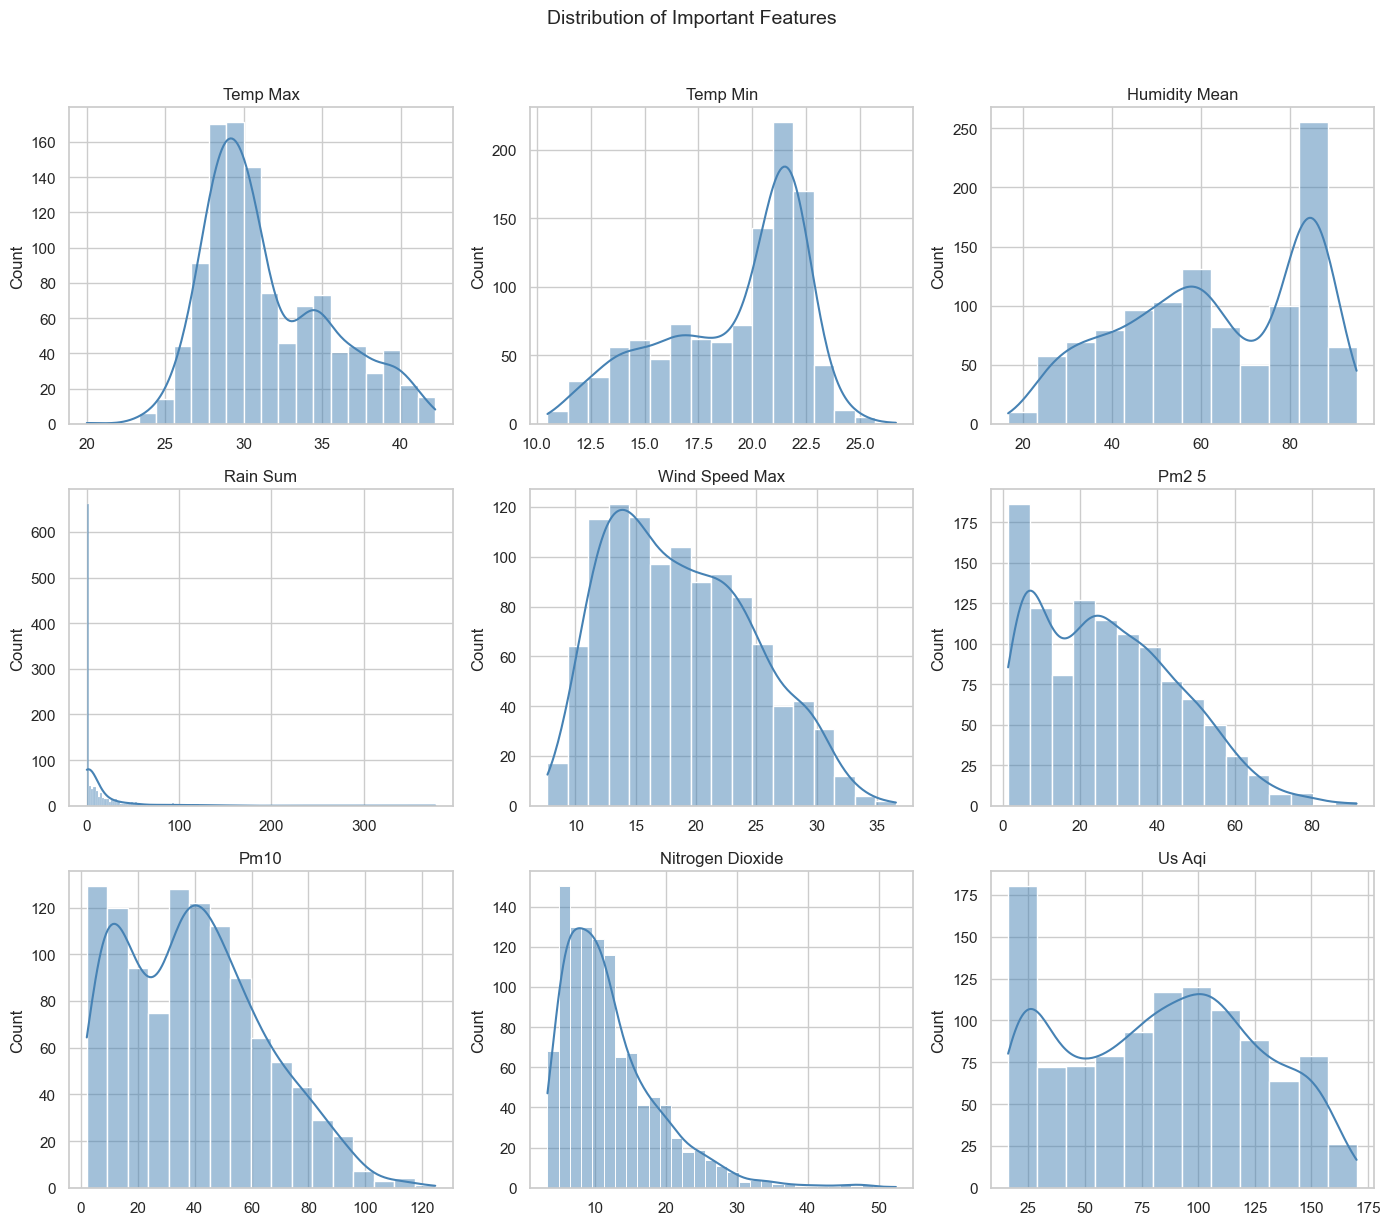

In [27]:
# Weather, pollutants, and target — exclude day and wind components (use wind_speed_max)
important_features = [
    'temp_max', 'temp_min', 'humidity_mean', 'rain_sum', 'wind_speed_max',
    'pm2_5', 'pm10', 'nitrogen_dioxide', 'us_aqi'
]

n = len(important_features)
ncols = 3
nrows = int(np.ceil(n / ncols))

fig, axes = plt.subplots(nrows, ncols, figsize=(14, 4 * nrows))
axes = axes.flatten()

for ax, col in zip(axes, important_features):
    sns.histplot(df[col], kde=True, ax=ax, color='steelblue', edgecolor='white')
    ax.set_title(col.replace('_', ' ').title())
    ax.set_xlabel('')

# Hide any empty subplots
for ax in axes[n:]:
    ax.set_visible(False)

plt.suptitle('Distribution of Important Features', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

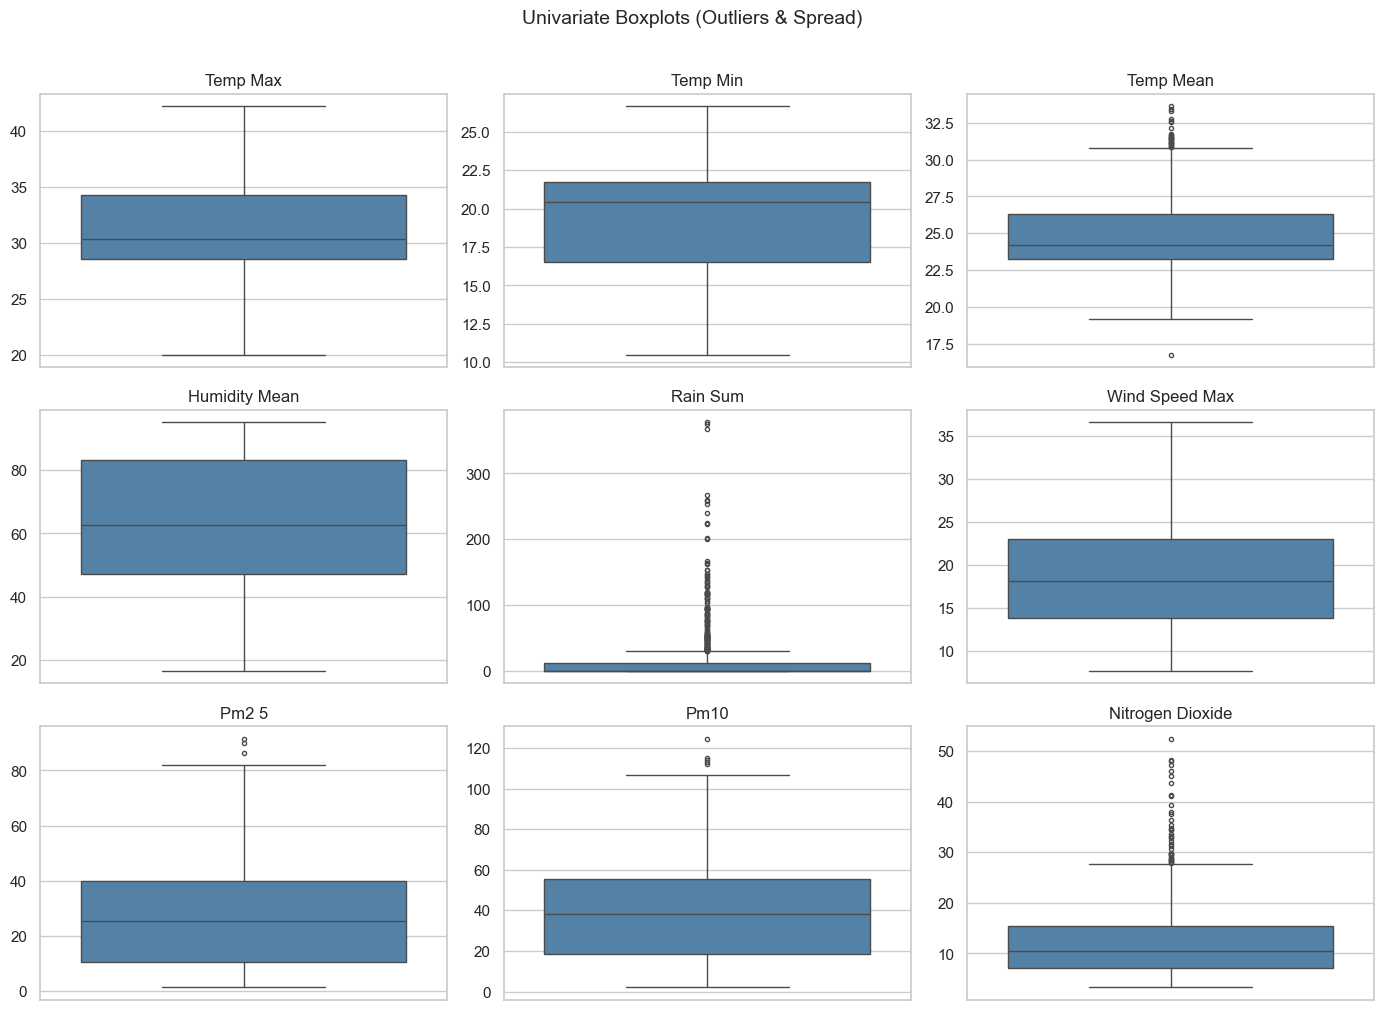

,mean,std,min,max,skew,abs_skew
rain_sum,15.69,38.82,0.00,377.40,4.67,4.67
nitrogen_dioxide,12.27,7.08,3.32,52.44,1.72,1.72
temp_max,31.50,4.01,20.00,42.20,0.70,0.70
temp_min,19.12,3.29,10.50,26.65,-0.70,0.70
temp_mean,24.83,2.69,16.74,33.64,0.63,0.63
pm2_5,27.45,18.28,1.45,91.48,0.54,0.54
pm10,39.54,24.57,2.08,124.55,0.46,0.46
wind_speed_max,18.80,5.90,7.69,36.58,0.41,0.41
humidity_mean,63.11,20.26,16.62,95.02,-0.29,0.29
us_aqi,83.50,42.39,16.00,170.08,0.02,0.02


In [28]:
# Boxplots — outlier & spread check
fig, axes = plt.subplots(3, 3, figsize=(14, 10))
axes = axes.flatten()

for ax, col in zip(axes, IMPORTANT_FEATURES):
    sns.boxplot(y=df[col], ax=ax, color="steelblue", fliersize=3)
    ax.set_title(col.replace("_", " ").title())
    ax.set_ylabel("")

for ax in axes[len(IMPORTANT_FEATURES):]:
    ax.set_visible(False)

plt.suptitle("Univariate Boxplots (Outliers & Spread)", fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

# Skewness & kurtosis — useful before choosing scalers / transforms
skew_stats = df[IMPORTANT_FEATURES].agg(["mean", "std", "min", "max", "skew"]).T.round(2)
skew_stats["abs_skew"] = skew_stats["skew"].abs()
display(skew_stats.sort_values("abs_skew", ascending=False))

C:\Users\ANISH\AppData\Local\Temp\ipykernel_1516\4065953902.py:26: UserWarning: The palette list has more values (6) than needed (4), which may not be intended.
  sns.barplot(


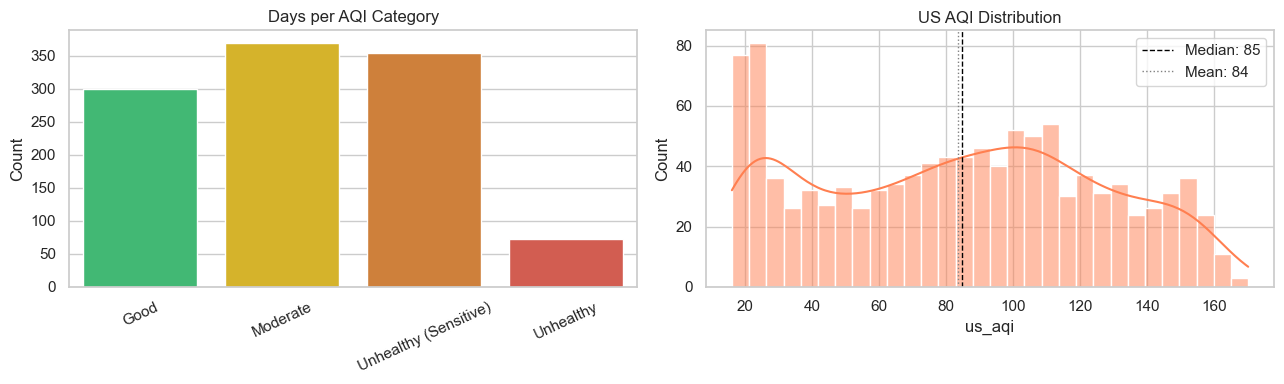

In [29]:
# US AQI category breakdown (intuitive target understanding)
def aqi_category(aqi):
    if aqi <= 50:
        return "Good"
    if aqi <= 100:
        return "Moderate"
    if aqi <= 150:
        return "Unhealthy (Sensitive)"
    if aqi <= 200:
        return "Unhealthy"
    if aqi <= 300:
        return "Very Unhealthy"
    return "Hazardous"

aqi_order = [
    "Good", "Moderate", "Unhealthy (Sensitive)",
    "Unhealthy", "Very Unhealthy", "Hazardous",
]
aqi_colors = ["#2ecc71", "#f1c40f", "#e67e22", "#e74c3c", "#9b59b6", "#7f0000"]

df["aqi_category"] = df[TARGET].apply(aqi_category)
cat_counts = df["aqi_category"].value_counts().reindex(aqi_order).dropna()

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

sns.barplot(
    x=cat_counts.index, y=cat_counts.values, ax=axes[0],
    hue=cat_counts.index, palette=aqi_colors, legend=False,
)
axes[0].set_title("Days per AQI Category")
axes[0].set_xlabel("")
axes[0].set_ylabel("Count")
axes[0].tick_params(axis="x", rotation=25)

sns.histplot(df[TARGET], bins=30, kde=True, ax=axes[1], color="coral")
axes[1].axvline(df[TARGET].median(), color="black", ls="--", lw=1, label=f"Median: {df[TARGET].median():.0f}")
axes[1].axvline(df[TARGET].mean(), color="gray", ls=":", lw=1, label=f"Mean: {df[TARGET].mean():.0f}")
axes[1].set_title("US AQI Distribution")
axes[1].legend()

plt.tight_layout()
plt.show()

## 3. Temporal patterns

Daily AQI often follows seasonal cycles. Check trends over time and monthly/seasonal variation before feature engineering.

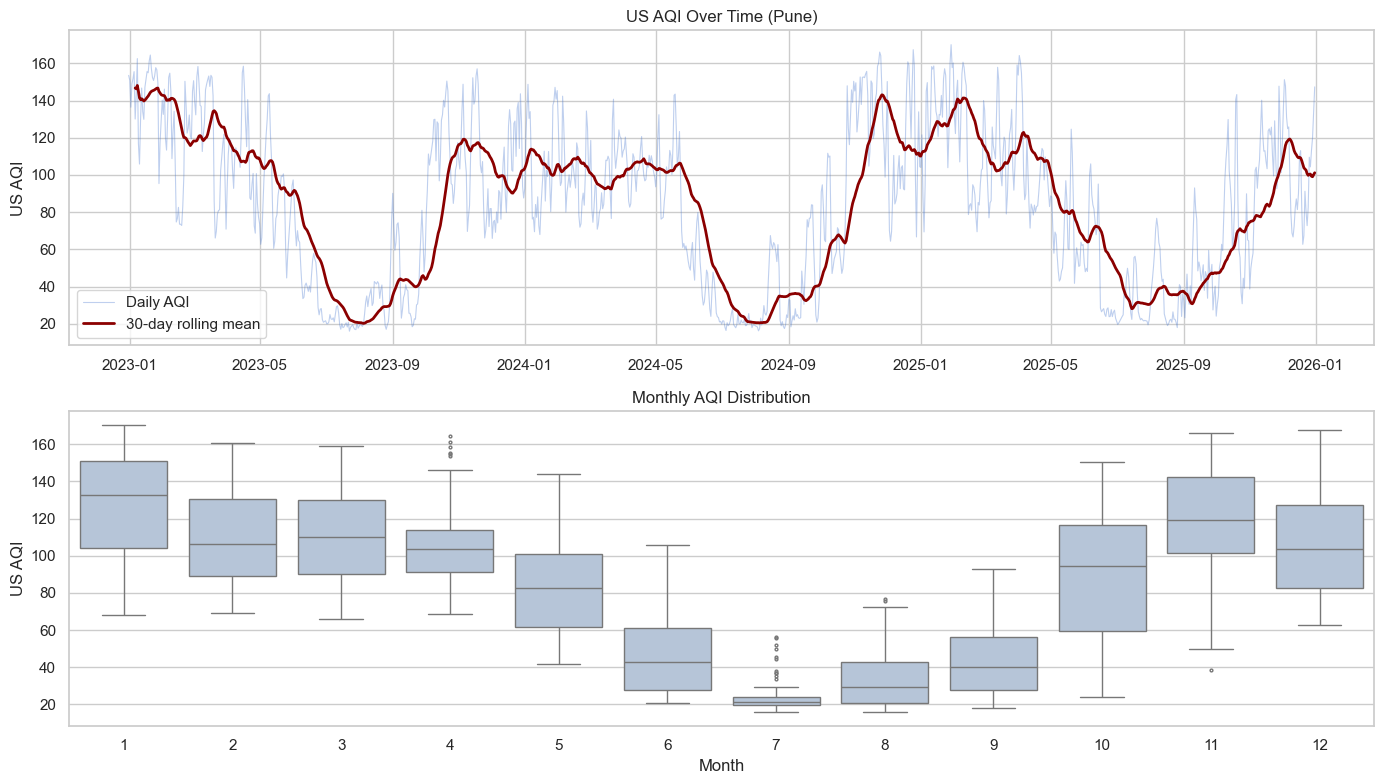

,pm2_5,pm10,nitrogen_dioxide,us_aqi
season,,,,
Winter,41.3,53.7,17.0,114.4
Spring,31.2,48.2,12.5,100.5
Summer,8.5,15.5,6.6,34.9
Monsoon,29.0,41.0,13.1,84.6


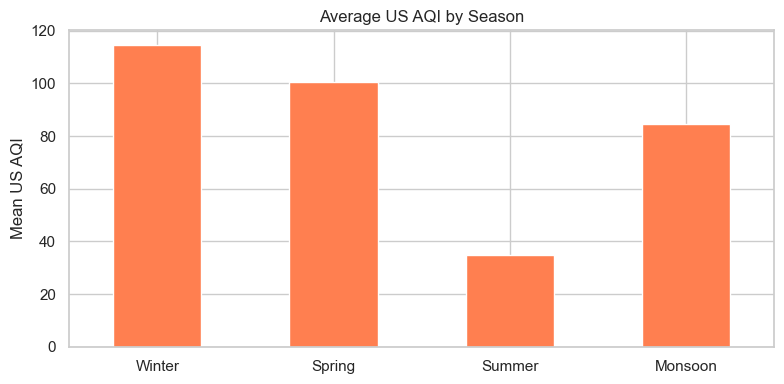

In [30]:
df = df.sort_values("day")
df["month"] = df["day"].dt.month
df["season"] = df["month"].map({
    12: "Winter", 1: "Winter", 2: "Winter",
    3: "Spring", 4: "Spring", 5: "Spring",
    6: "Summer", 7: "Summer", 8: "Summer",
    9: "Monsoon", 10: "Monsoon", 11: "Monsoon",
})
season_order = ["Winter", "Spring", "Summer", "Monsoon"]

fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=False)

# Time series of AQI with 30-day rolling mean
axes[0].plot(df["day"], df[TARGET], alpha=0.35, lw=0.8, label="Daily AQI")
axes[0].plot(
    df["day"], df[TARGET].rolling(30, min_periods=7).mean(),
    color="darkred", lw=2, label="30-day rolling mean",
)
axes[0].set_title("US AQI Over Time (Pune)")
axes[0].set_ylabel("US AQI")
axes[0].legend()

# Monthly boxplot — seasonality at a glance
sns.boxplot(
    data=df, x="month", y=TARGET, ax=axes[1],
    color="lightsteelblue", fliersize=2,
)
axes[1].set_title("Monthly AQI Distribution")
axes[1].set_xlabel("Month")
axes[1].set_ylabel("US AQI")

plt.tight_layout()
plt.show()

# Seasonal summary for pollutants + AQI
seasonal = df.groupby("season")[POLLUTANT_FEATURES + [TARGET]].mean().reindex(season_order)
display(seasonal.round(1))

fig, ax = plt.subplots(figsize=(8, 4))
seasonal[TARGET].plot(kind="bar", ax=ax, color="coral", edgecolor="white")
ax.set_title("Average US AQI by Season")
ax.set_xlabel("")
ax.set_ylabel("Mean US AQI")
ax.tick_params(axis="x", rotation=0)
plt.tight_layout()
plt.show()

## 4. Bivariate analysis

Correlation heatmaps reveal multicollinearity (e.g. PM₂.₅, PM₁₀, AQI). Scatter plots show how each predictor relates to the target.

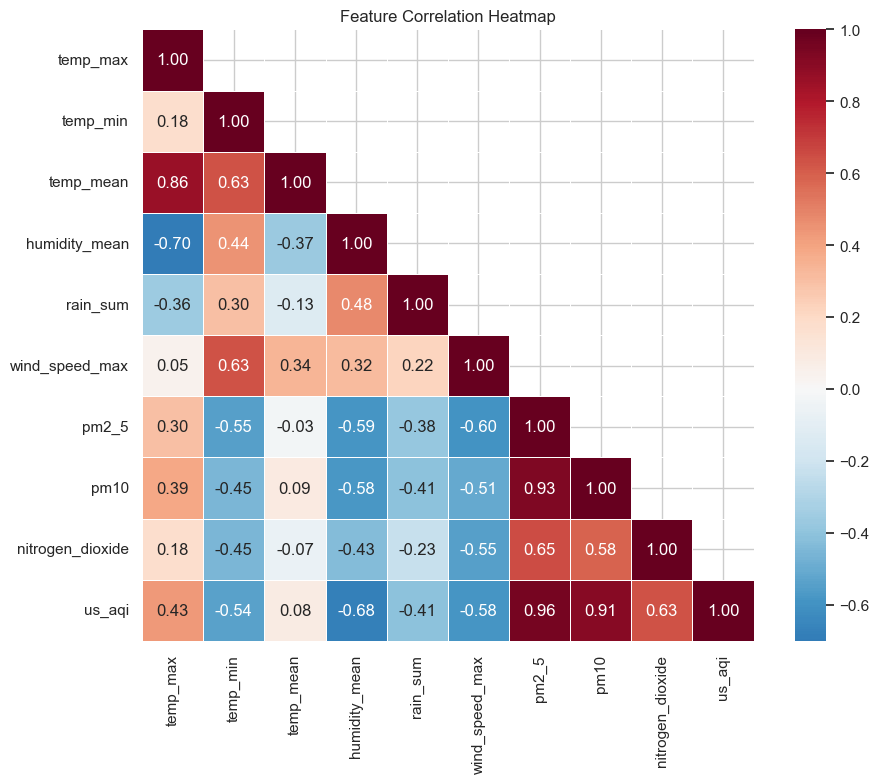

Correlation with US AQI:


,corr_with_aqi
pm2_5,0.958
pm10,0.909
humidity_mean,-0.677
nitrogen_dioxide,0.635
wind_speed_max,-0.585
temp_min,-0.537
temp_max,0.430
rain_sum,-0.406
temp_mean,0.077


In [31]:
corr = df[IMPORTANT_FEATURES].corr()

mask = np.triu(np.ones_like(corr, dtype=bool), k=1)
fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(
    corr, mask=mask, annot=True, fmt=".2f", cmap="RdBu_r",
    center=0, square=True, linewidths=0.5, ax=ax,
)
ax.set_title("Feature Correlation Heatmap")
plt.tight_layout()
plt.show()

# Top features most correlated with AQI
target_corr = (
    corr[TARGET].drop(TARGET).sort_values(key=abs, ascending=False)
)
print("Correlation with US AQI:")
display(target_corr.to_frame("corr_with_aqi").round(3))

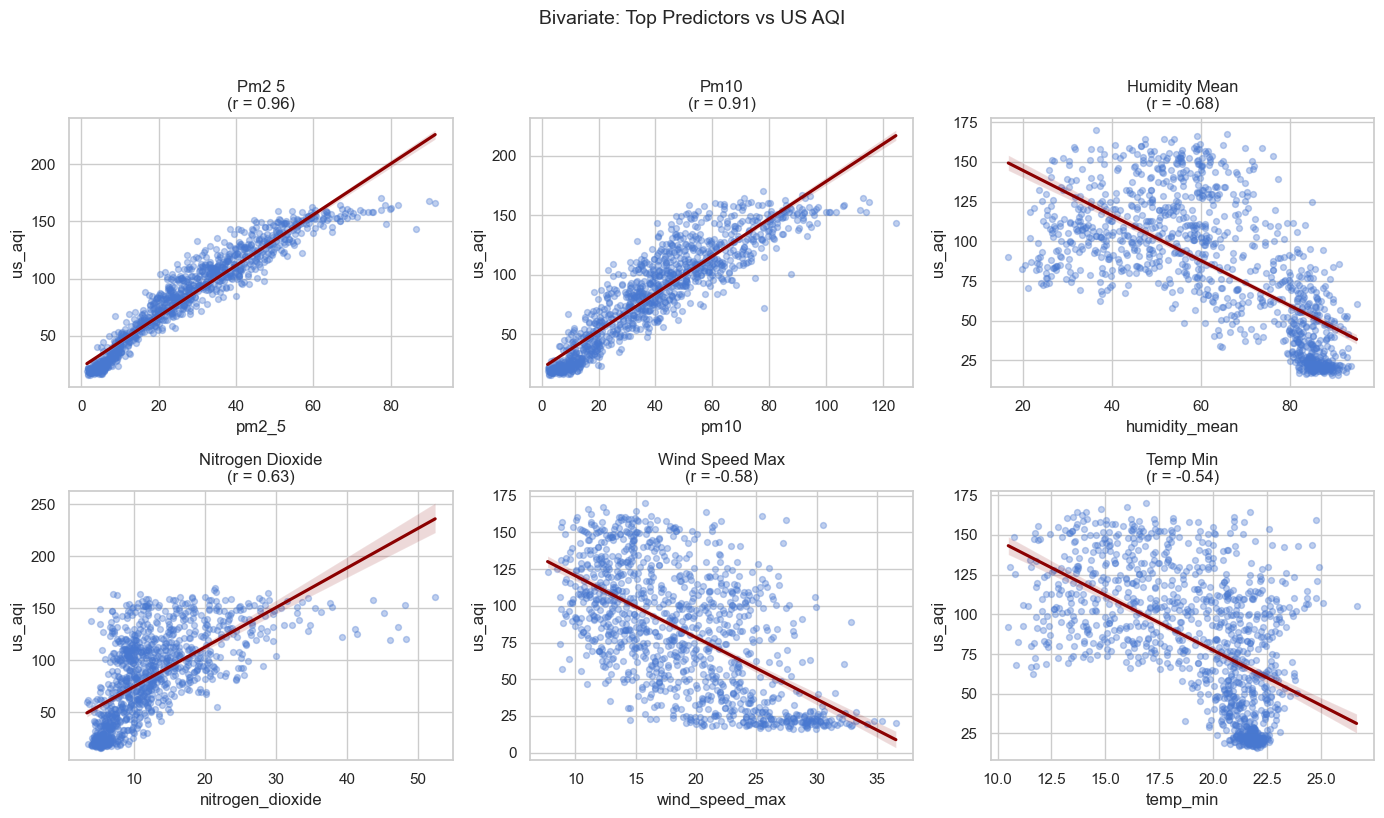

In [32]:
# Scatter + regression line vs target (top 6 by |correlation|)
top_predictors = target_corr.head(6).index.tolist()

fig, axes = plt.subplots(2, 3, figsize=(14, 8))
axes = axes.flatten()

for ax, col in zip(axes, top_predictors):
    sns.regplot(
        data=df, x=col, y=TARGET, ax=ax,
        scatter_kws={"alpha": 0.35, "s": 18}, line_kws={"color": "darkred"},
    )
    r = target_corr[col]
    ax.set_title(f"{col.replace('_', ' ').title()}\n(r = {r:.2f})")

plt.suptitle("Bivariate: Top Predictors vs US AQI", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

C:\Users\ANISH\AppData\Local\Temp\ipykernel_1516\2479501335.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x="rainy_day", y=TARGET, ax=axes[0], palette="Set2")


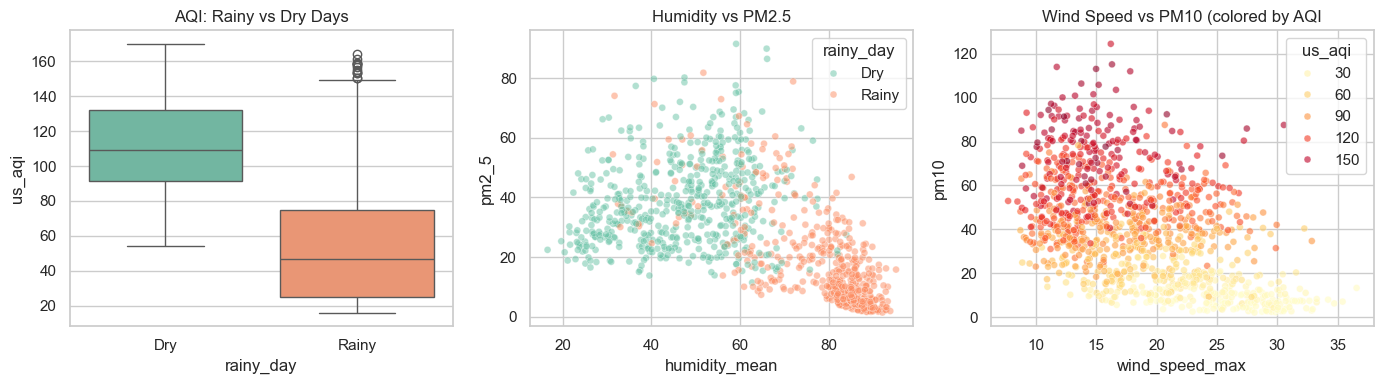

In [33]:
# Weather vs pollution — do rainy / humid days differ in air quality?
df["rainy_day"] = np.where(df["rain_sum"] > 0, "Rainy", "Dry")

fig, axes = plt.subplots(1, 3, figsize=(14, 4))

sns.boxplot(data=df, x="rainy_day", y=TARGET, ax=axes[0], palette="Set2")
axes[0].set_title("AQI: Rainy vs Dry Days")

sns.scatterplot(
    data=df, x="humidity_mean", y="pm2_5", hue="rainy_day",
    alpha=0.5, s=25, ax=axes[1], palette="Set2",
)
axes[1].set_title("Humidity vs PM2.5")

sns.scatterplot(
    data=df, x="wind_speed_max", y="pm10", hue=TARGET,
    palette="YlOrRd", alpha=0.6, s=25, ax=axes[2],
)
axes[2].set_title("Wind Speed vs PM10 (colored by AQI")

plt.tight_layout()
plt.show()

## 5. Multivariate view & pre-modeling checks

Pairplots give a compact multivariate snapshot. IQR outlier counts and high pairwise correlations help decide scaling, feature selection, and whether to drop redundant columns.

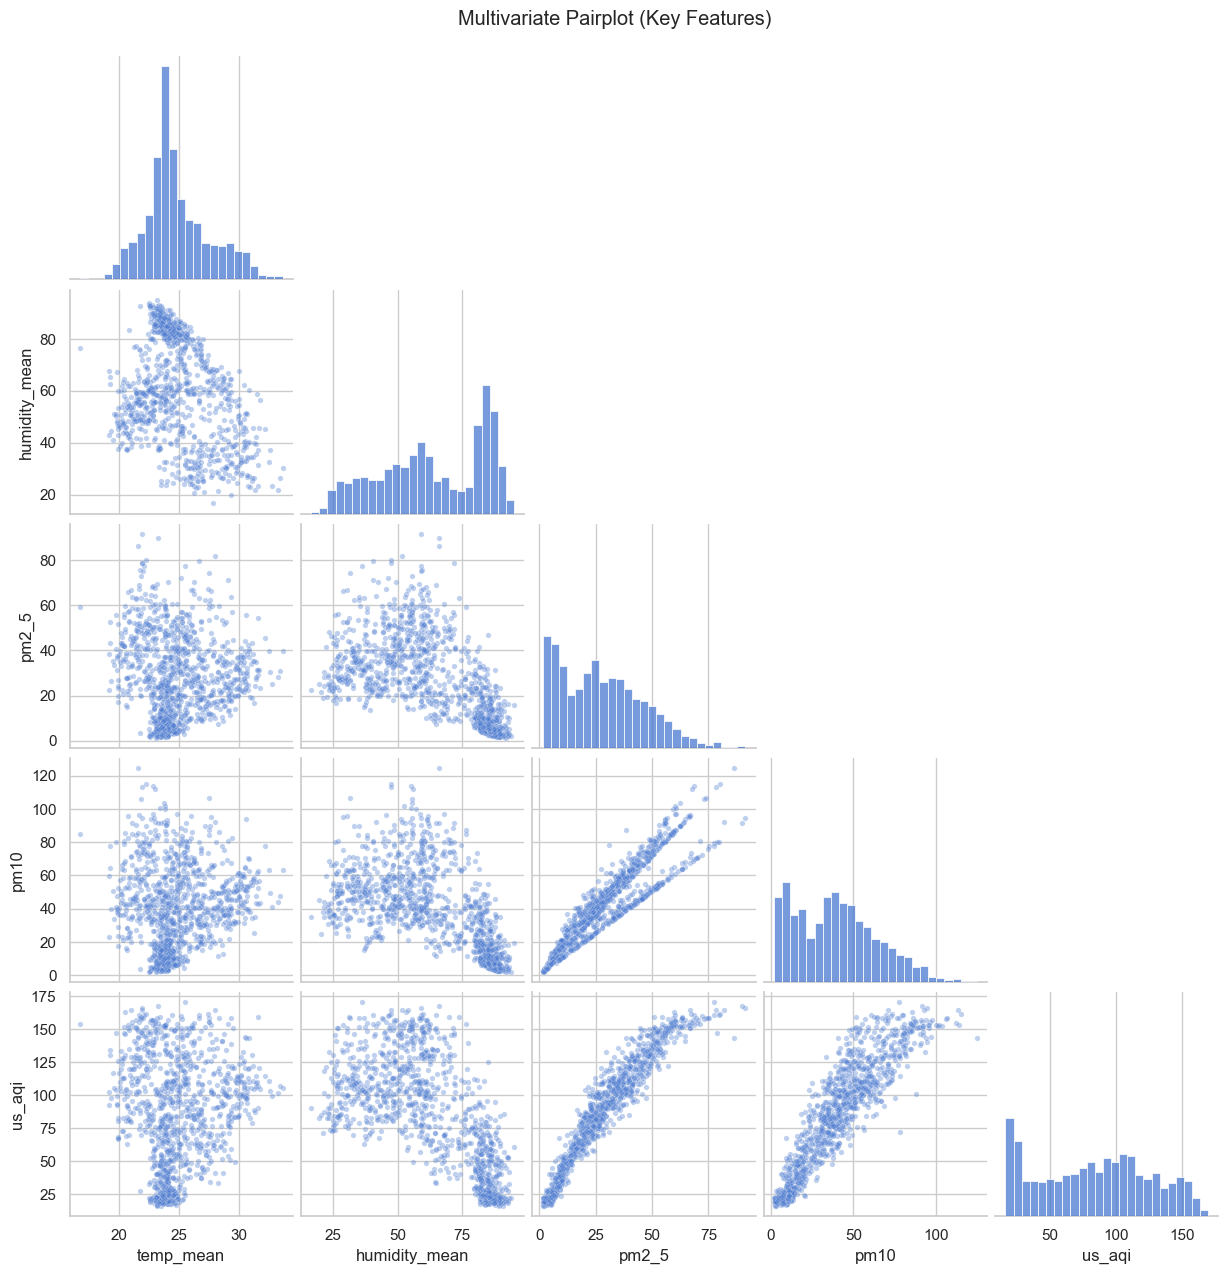

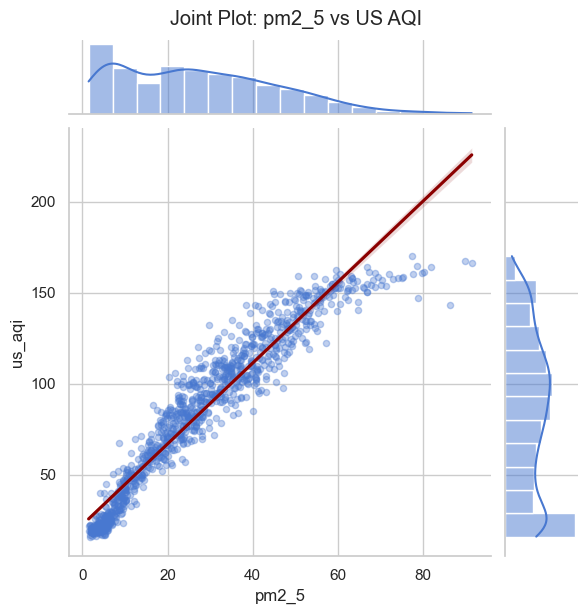

In [34]:
# Pairplot on a focused subset (full pairplot is too heavy for 10+ features)
pair_features = ["temp_mean", "humidity_mean", "pm2_5", "pm10", TARGET]
g = sns.pairplot(
    df[pair_features], corner=True, diag_kind="hist",
    plot_kws={"alpha": 0.35, "s": 15}, diag_kws={"bins": 25},
)
g.fig.suptitle("Multivariate Pairplot (Key Features)", y=1.02)
plt.show()

# Joint plot — strongest linear relationship with AQI
best_feat = target_corr.abs().idxmax()
g = sns.jointplot(
    data=df, x=best_feat, y=TARGET, kind="reg",
    height=6, scatter_kws={"alpha": 0.35, "s": 20},
    line_kws={"color": "darkred"},
)
g.fig.suptitle(f"Joint Plot: {best_feat} vs US AQI", y=1.02)
plt.show()

In [35]:
# IQR-based outlier count per feature
def iqr_outlier_count(series):
    q1, q3 = series.quantile(0.25), series.quantile(0.75)
    iqr = q3 - q1
    lower, upper = q1 - 1.5 * iqr, q3 + 1.5 * iqr
    return ((series < lower) | (series > upper)).sum()

outlier_report = pd.DataFrame({
    "iqr_outliers": [iqr_outlier_count(df[c]) for c in IMPORTANT_FEATURES],
    "pct_outliers": [
        iqr_outlier_count(df[c]) / len(df) * 100 for c in IMPORTANT_FEATURES
    ],
}, index=IMPORTANT_FEATURES).round(2)

# Flag highly correlated pairs (multicollinearity risk)
high_corr_pairs = []
for i, c1 in enumerate(IMPORTANT_FEATURES):
    for c2 in IMPORTANT_FEATURES[i + 1:]:
        r = corr.loc[c1, c2]
        if abs(r) >= 0.85:
            high_corr_pairs.append({"feature_1": c1, "feature_2": c2, "corr": round(r, 3)})

print("=== Pre-modeling summary ===")
print(f"Target range: {df[TARGET].min():.1f} – {df[TARGET].max():.1f}")
print(f"Most skewed feature: {skew_stats['abs_skew'].idxmax()} (skew={skew_stats.loc[skew_stats['abs_skew'].idxmax(), 'skew']:.2f})")
print(f"Strongest predictor of AQI: {best_feat} (r={target_corr[best_feat]:.2f})")

display(outlier_report.sort_values("pct_outliers", ascending=False))
if high_corr_pairs:
    display(pd.DataFrame(high_corr_pairs))
else:
    print("No feature pairs with |r| >= 0.85")

=== Pre-modeling summary ===
Target range: 16.0 – 170.1
Most skewed feature: rain_sum (skew=4.67)
Strongest predictor of AQI: pm2_5 (r=0.96)


,iqr_outliers,pct_outliers
rain_sum,156,14.22
nitrogen_dioxide,39,3.56
temp_mean,28,2.55
pm10,5,0.46
pm2_5,3,0.27
temp_max,0,0.00
temp_min,0,0.00
humidity_mean,0,0.00
wind_speed_max,0,0.00
us_aqi,0,0.00


,feature_1,feature_2,corr
0,temp_max,temp_mean,0.857
1,pm2_5,pm10,0.933
2,pm2_5,us_aqi,0.958
3,pm10,us_aqi,0.909


## 6. Feature-engineered dataset (`df2`) — before vs after

Visual checks for the forecasting pipeline: rain encoding, lag features, cyclical seasonality, leakage removal, and predictor–target strength for **next-day AQI**.

C:\Users\ANISH\AppData\Local\Temp\ipykernel_1516\2408723306.py:22: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df2, x="is_raining", ax=axes[1], palette="Set2")
C:\Users\ANISH\AppData\Local\Temp\ipykernel_1516\2408723306.py:24: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[1].set_xticklabels(["Dry (0)", "Rainy (1)"])


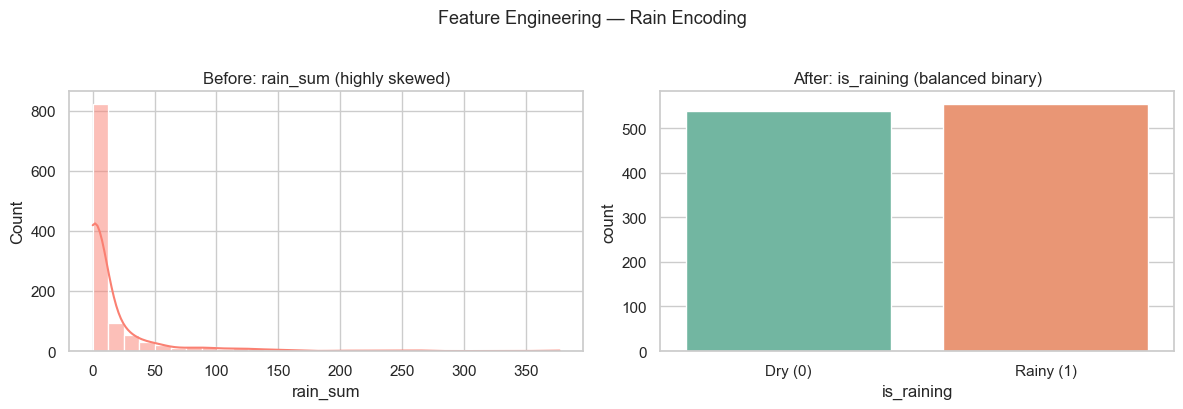

C:\Users\ANISH\AppData\Local\Temp\ipykernel_1516\2408723306.py:39: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=pairs.index, y=pairs.values, ax=ax, palette=["#e74c3c", "#2ecc71"])


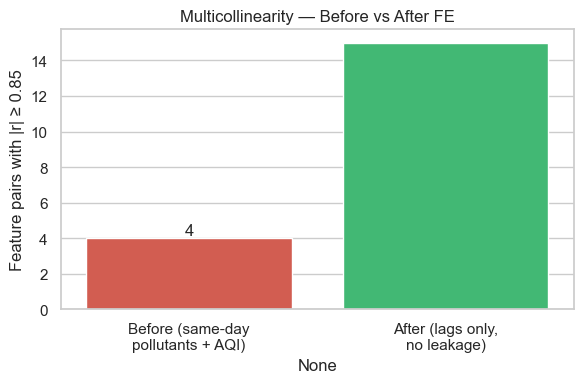

In [36]:
# --- df2 feature groups (forecasting setup) ---
TARGET2 = "Target_AQI_Next_Day"
LAG_FEATURES = [c for c in df2.columns if "_lag_" in c]
ENGINEERED = ["is_raining", "month_sin", "month_cos"]
X_FEATURES = [c for c in df2.columns if c not in ["day", TARGET2, "Target_PM25_Next_Day"]]

def count_high_corr_pairs(corr_matrix, threshold=0.85):
    cols = corr_matrix.columns
    n = 0
    for i, c1 in enumerate(cols):
        for c2 in cols[i + 1 :]:
            if abs(corr_matrix.loc[c1, c2]) >= threshold:
                n += 1
    return n

# 1) Rain skew fix: continuous rain_sum → binary is_raining
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

sns.histplot(df["rain_sum"], kde=True, ax=axes[0], color="salmon", bins=30)
axes[0].set_title("Before: rain_sum (highly skewed)")

sns.countplot(data=df2, x="is_raining", ax=axes[1], palette="Set2")
axes[1].set_title("After: is_raining (balanced binary)")
axes[1].set_xticklabels(["Dry (0)", "Rainy (1)"])

plt.suptitle("Feature Engineering — Rain Encoding", fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

# 2) Multicollinearity reduction after dropping same-day pollution
corr_before = df[IMPORTANT_FEATURES].corr()
corr_after = df2[X_FEATURES + [TARGET2]].corr()

fig, ax = plt.subplots(figsize=(6, 4))
pairs = pd.Series({
    "Before (same-day\npollutants + AQI)": count_high_corr_pairs(corr_before),
    "After (lags only,\nno leakage)": count_high_corr_pairs(corr_after),
})
sns.barplot(x=pairs.index, y=pairs.values, ax=ax, palette=["#e74c3c", "#2ecc71"])
ax.set_ylabel("Feature pairs with |r| ≥ 0.85")
ax.set_title("Multicollinearity — Before vs After FE")
ax.bar_label(ax.containers[0])
plt.tight_layout()
plt.show()

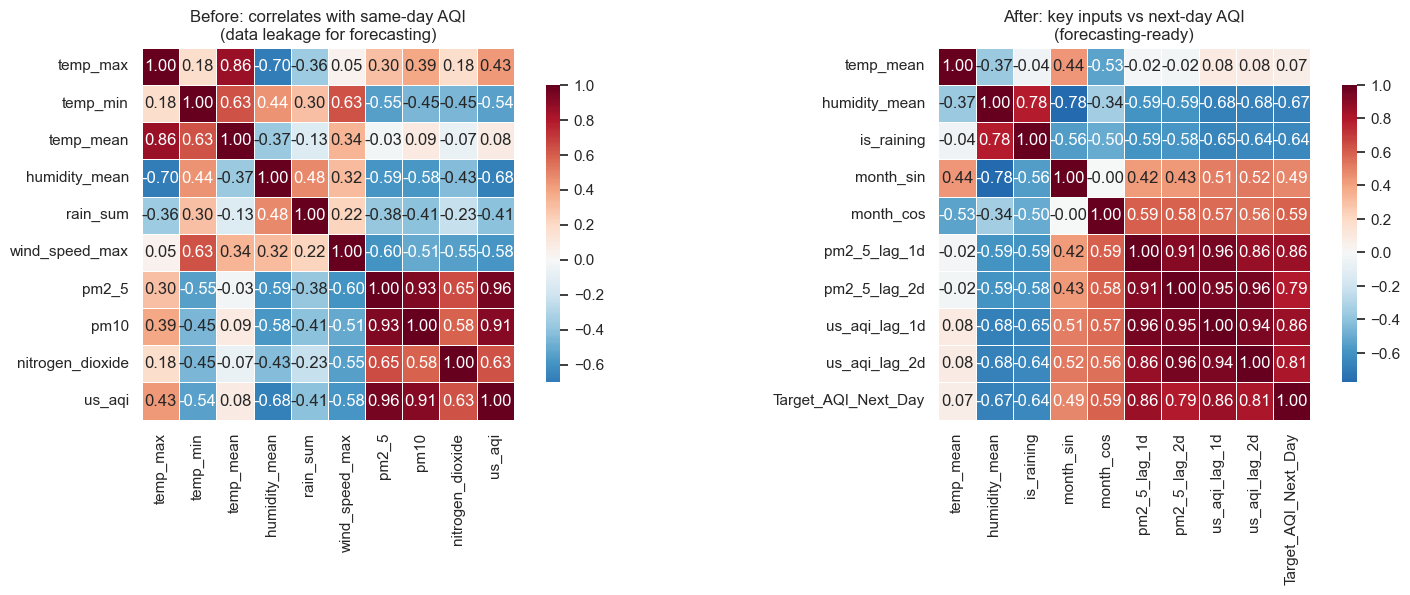

In [37]:
# 3) Side-by-side correlation heatmaps — same-day vs next-day forecasting target
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sns.heatmap(
    corr_before, annot=True, fmt=".2f", cmap="RdBu_r", center=0,
    square=True, linewidths=0.4, ax=axes[0], cbar_kws={"shrink": 0.8},
)
axes[0].set_title("Before: correlates with same-day AQI\n(data leakage for forecasting)")

# Show a focused subset on the right (model inputs + target)
focus_cols = (
    ["temp_mean", "humidity_mean", "is_raining", "month_sin", "month_cos"]
    + [c for c in LAG_FEATURES if "aqi" in c or "pm2" in c]
    + [TARGET2]
)
focus_cols = [c for c in focus_cols if c in df2.columns]
sns.heatmap(
    df2[focus_cols].corr(), annot=True, fmt=".2f", cmap="RdBu_r", center=0,
    square=True, linewidths=0.4, ax=axes[1], cbar_kws={"shrink": 0.8},
)
axes[1].set_title("After: key inputs vs next-day AQI\n(forecasting-ready)")

plt.tight_layout()
plt.show()

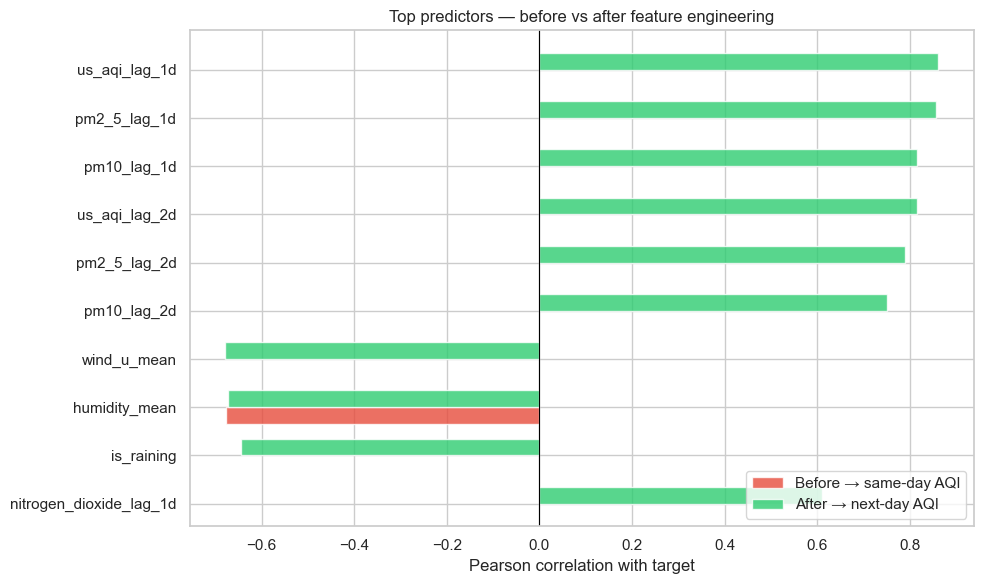

In [38]:
# 4) Predictor strength for ML — |correlation| with target (before vs after)
corr_before_target = df[IMPORTANT_FEATURES].corr()[TARGET].drop(TARGET)
corr_after_target = df2[X_FEATURES + [TARGET2]].corr()[TARGET2].drop(TARGET2)

compare = pd.DataFrame({
    "Same-day AQI (before)": corr_before_target,
    "Next-day AQI (after)": corr_after_target.reindex(corr_before_target.index, fill_value=np.nan),
})

# Add new lag-only features not in raw df
new_feats = [c for c in corr_after_target.index if c not in compare.index]
compare = pd.concat([
    compare,
    pd.DataFrame({"Next-day AQI (after)": corr_after_target[new_feats]}),
])

top = compare["Next-day AQI (after)"].abs().sort_values(ascending=False).head(10)
plot_df = compare.loc[top.index].copy()
plot_df = plot_df.sort_values("Next-day AQI (after)", key=abs, ascending=True)

fig, ax = plt.subplots(figsize=(10, 6))
y = np.arange(len(plot_df))
h = 0.35
ax.barh(y - h / 2, plot_df["Same-day AQI (before)"], height=h, label="Before → same-day AQI", color="#e74c3c", alpha=0.8)
ax.barh(y + h / 2, plot_df["Next-day AQI (after)"], height=h, label="After → next-day AQI", color="#2ecc71", alpha=0.8)
ax.set_yticks(y)
ax.set_yticklabels(plot_df.index)
ax.axvline(0, color="black", lw=0.8)
ax.set_xlabel("Pearson correlation with target")
ax.set_title("Top predictors — before vs after feature engineering")
ax.legend(loc="lower right")
plt.tight_layout()
plt.show()

C:\Users\ANISH\AppData\Local\Temp\ipykernel_1516\1926142940.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=lag_corr.values, y=lag_corr.index, ax=ax, palette=colors, orient="h")


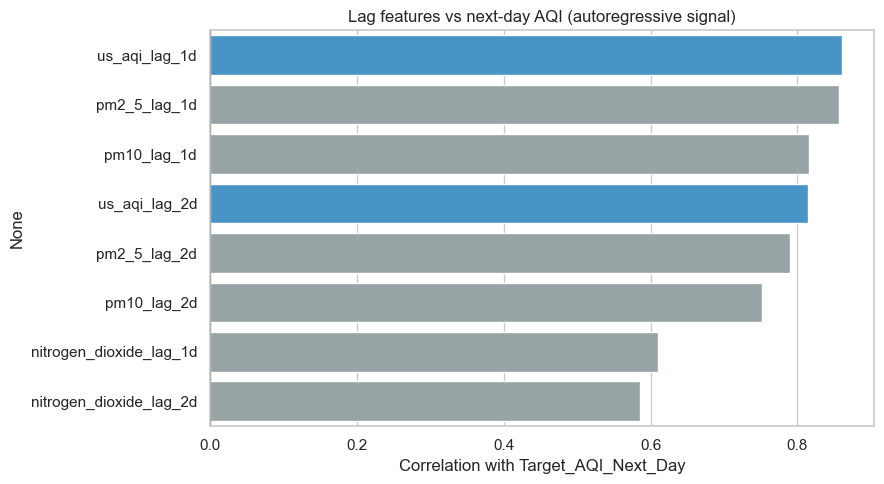

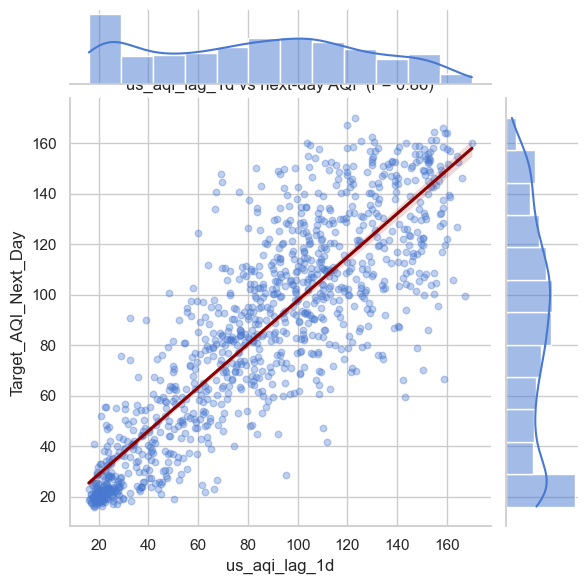

In [39]:
# 5) Lag features — main time-series signal for forecasting
lag_corr = df2[LAG_FEATURES + [TARGET2]].corr()[TARGET2].drop(TARGET2).sort_values(key=abs, ascending=False)

fig, ax = plt.subplots(figsize=(9, 5))
colors = ["#3498db" if "aqi" in f else "#95a5a6" for f in lag_corr.index]
sns.barplot(x=lag_corr.values, y=lag_corr.index, ax=ax, palette=colors, orient="h")
ax.axvline(0, color="black", lw=0.8)
ax.set_xlabel(f"Correlation with {TARGET2}")
ax.set_title("Lag features vs next-day AQI (autoregressive signal)")
plt.tight_layout()
plt.show()

# 6) Strongest ML predictor — yesterday's AQI vs tomorrow's AQI
g = sns.jointplot(
    data=df2, x="us_aqi_lag_1d", y=TARGET2, kind="reg", height=6,
    scatter_kws={"alpha": 0.35, "s": 22}, line_kws={"color": "darkred"},
)
r = df2["us_aqi_lag_1d"].corr(df2[TARGET2])
g.ax_joint.set_title(f"us_aqi_lag_1d vs next-day AQI  (r = {r:.2f})")
plt.show()

C:\Users\ANISH\AppData\Local\Temp\ipykernel_1516\894495989.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df2, x="is_raining", y=TARGET2, ax=axes[1], palette="Set2")
C:\Users\ANISH\AppData\Local\Temp\ipykernel_1516\894495989.py:15: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[1].set_xticklabels(["Dry", "Rainy"])


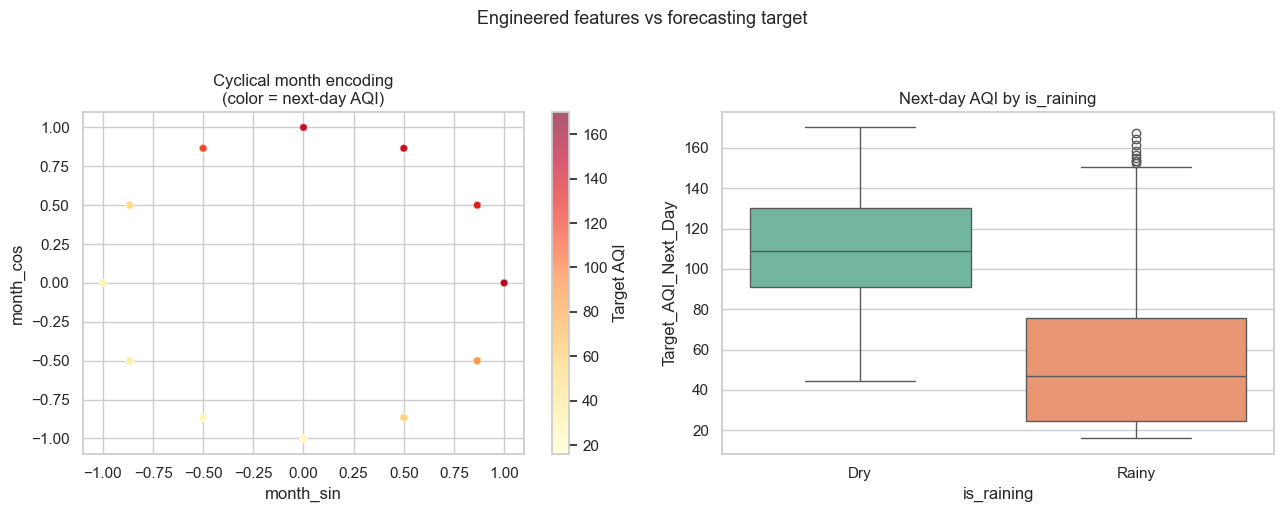

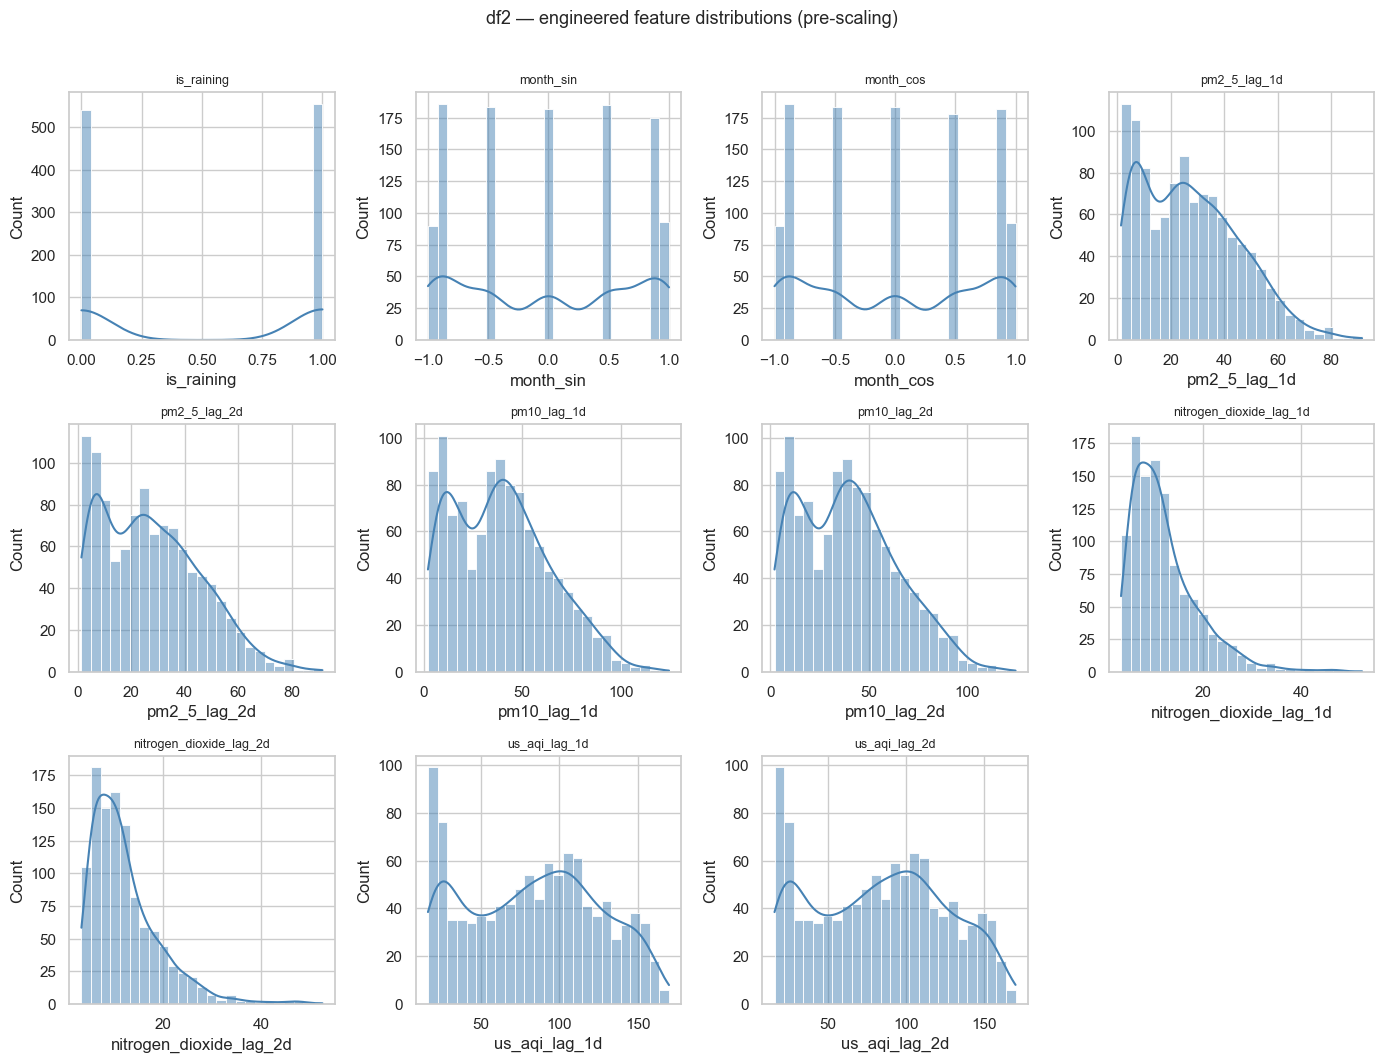

In [40]:
# 7) Cyclical month encoding — seasonality without Jan/Dec discontinuity
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

sc = axes[0].scatter(
    df2["month_sin"], df2["month_cos"], c=df2[TARGET2],
    cmap="YlOrRd", alpha=0.65, s=28, edgecolors="white", linewidth=0.3,
)
axes[0].set_xlabel("month_sin")
axes[0].set_ylabel("month_cos")
axes[0].set_title("Cyclical month encoding\n(color = next-day AQI)")
plt.colorbar(sc, ax=axes[0], label="Target AQI")

# AQI by rain flag — engineered binary feature vs target
sns.boxplot(data=df2, x="is_raining", y=TARGET2, ax=axes[1], palette="Set2")
axes[1].set_xticklabels(["Dry", "Rainy"])
axes[1].set_title("Next-day AQI by is_raining")

plt.suptitle("Engineered features vs forecasting target", fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

# 8) Distributions of all model inputs (sanity check before scaling)
plot_feats = ENGINEERED + LAG_FEATURES
ncols, nrows = 4, int(np.ceil(len(plot_feats) / 4))
fig, axes = plt.subplots(nrows, ncols, figsize=(14, 3.5 * nrows))
axes = axes.flatten()

for ax, col in zip(axes, plot_feats):
    sns.histplot(df2[col], kde=True, ax=ax, color="steelblue", bins=25)
    ax.set_title(col, fontsize=9)

for ax in axes[len(plot_feats):]:
    ax.set_visible(False)

plt.suptitle("df2 — engineered feature distributions (pre-scaling)", fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

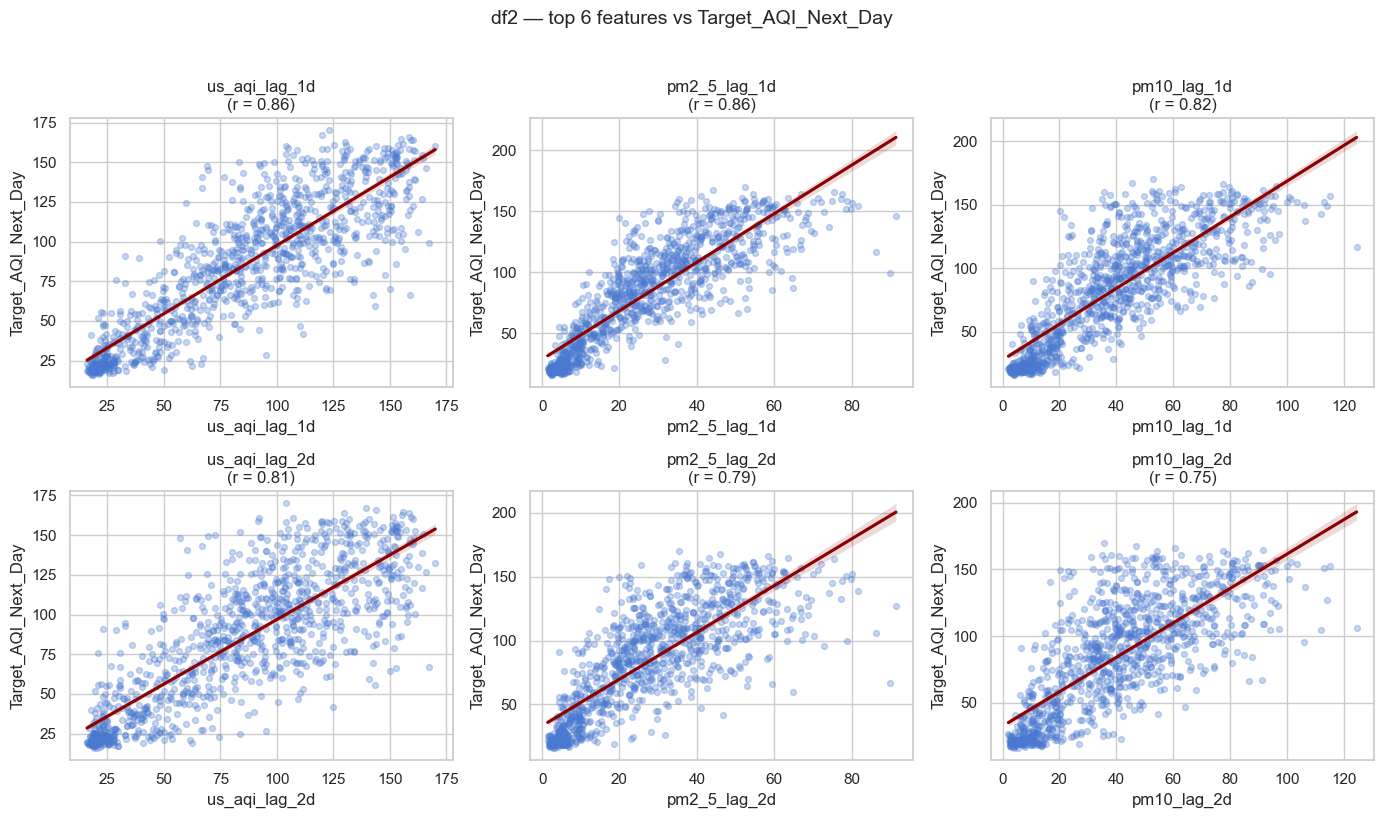

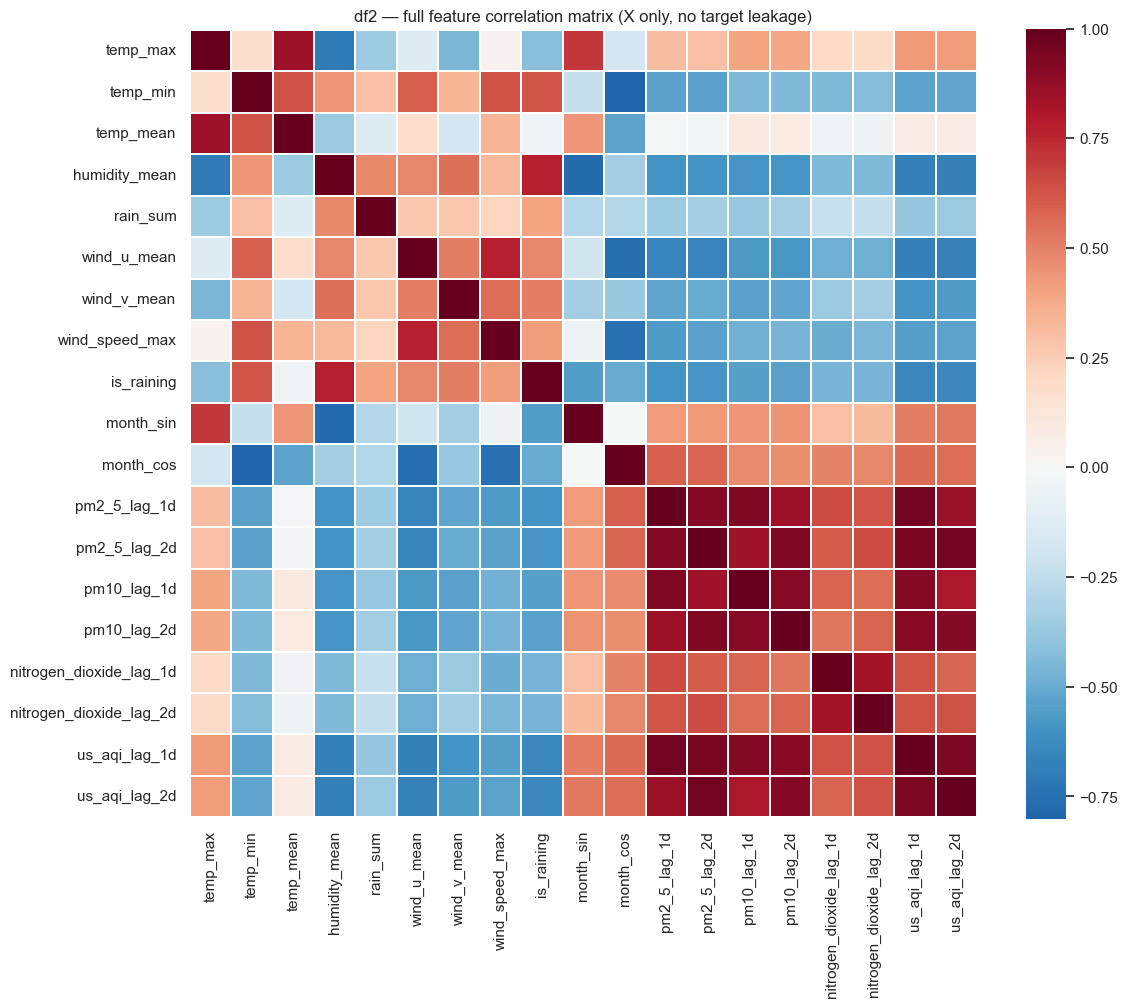

In [41]:
# 9) Top weather + lag predictors vs next-day AQI (regression-ready scatter grid)
top_ml_feats = (
    df2[X_FEATURES].corrwith(df2[TARGET2]).abs().sort_values(ascending=False).head(6).index.tolist()
)

fig, axes = plt.subplots(2, 3, figsize=(14, 8))
axes = axes.flatten()

for ax, col in zip(axes, top_ml_feats):
    r = df2[col].corr(df2[TARGET2])
    sns.regplot(
        data=df2, x=col, y=TARGET2, ax=ax,
        scatter_kws={"alpha": 0.3, "s": 18}, line_kws={"color": "darkred"},
    )
    ax.set_title(f"{col}\n(r = {r:.2f})")

plt.suptitle("df2 — top 6 features vs Target_AQI_Next_Day", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

# 10) Full model-feature correlation heatmap (inputs only, for pipeline / feature selection)
fig, ax = plt.subplots(figsize=(12, 10))
sns.heatmap(
    df2[X_FEATURES].corr(), cmap="RdBu_r", center=0, square=True,
    linewidths=0.3, ax=ax,
)
ax.set_title("df2 — full feature correlation matrix (X only, no target leakage)")
plt.tight_layout()
plt.show()